# City Predictor Machine-learning Project

Below is extensive testing and protoryping to better understand which model architecture is best fit for the task at hand.
That is, we determine which model is best at determining if a given data point describes **New York City**, **Dubai**,
**Rio de Janeiro**, or **Paris**. We will be exploring some tranformations of the provided dataset, and test out the performance of various model families.

In [1]:
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Now, we load the data into pandas:

In [2]:
data = pd.read_csv("data/cleaned_dataset.csv")
del data['id'] #remove id column since it is of no use
data

,Popularity,Virality,Architecure,Parties,Company,Relatable,Temperature,Languages,Styles,Quote,Label
0,4,1.0,2.0,1,Co-worker,"Skyscrapers=>6,Sport=>4,Art and Music=>2,Carni...",25,7.0,100,Slavery,Dubai
1,4,3.0,5.0,2,Co-worker,"Skyscrapers=>6,Sport=>1,Art and Music=>2,Carni...",20,3.0,4,"Wherever there is great property, there is gre...",Dubai
2,5,4.0,5.0,1,"Partner,Friends","Skyscrapers=>6,Sport=>2,Art and Music=>3,Carni...",32,5.0,4,Futuristic land,Dubai
3,5,4.0,4.0,1,"Partner,Friends","Skyscrapers=>6,Sport=>5,Art and Music=>1,Carni...",23,10.0,3,The city where anything is possible,Dubai
4,4,3.0,3.0,3,"Partner,Friends,Siblings","Skyscrapers=>6,Sport=>4,Art and Music=>1,Carni...",20,10.0,5,"If you can think of a high building, it probab...",Dubai
...,...,...,...,...,...,...,...,...,...,...,...
1457,4,2.0,5.0,3,"Partner,Friends,Siblings","Skyscrapers=>2,Sport=>1,Art and Music=>4,Carni...",5,2.0,2,"""The average piece of junk is probably more me...",Paris
1458,5,3.0,4.0,2,"Partner,Co-worker","Skyscrapers=>1,Sport=>3,Art and Music=>6,Carni...",7,2.0,4,Oui oui baguette,Paris
1459,2,1.0,3.0,4,Friends,"Skyscrapers=>2,Sport=>3,Art and Music=>6,Carni...",9,87.0,67,E OhÂ,Paris
1460,5,4.0,5.0,3,"Partner,Friends","Skyscrapers=>5,Sport=>6,Art and Music=>2,Carni...",15,1.0,15,croissants and cigarettesÂ,Paris


Now, since the "relatable" column has too many unique values, and won't provide much insight for any standard models, we split the relatability scores
into seperate columns:

In [3]:
upd_data = pd.read_csv("data/cleaned_dataset_split.csv")
del upd_data['id'] #remove id column since it is of no use
upd_data

,Popularity,Virality,Architecure,Parties,Company,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles,Quote,Label
0,4,1.0,2.0,1,Co-worker,2,1,3.0,5,6,4,25,7.0,100,Slavery,Dubai
1,4,3.0,5.0,2,Co-worker,2,3,4.0,5,6,1,20,3.0,4,"Wherever there is great property, there is gre...",Dubai
2,5,4.0,5.0,1,"Partner,Friends",3,3,4.0,5,6,2,32,5.0,4,Futuristic land,Dubai
3,5,4.0,4.0,1,"Partner,Friends",1,2,4.0,3,6,5,23,10.0,3,The city where anything is possible,Dubai
4,4,3.0,3.0,3,"Partner,Friends,Siblings",1,2,3.0,5,6,4,20,10.0,5,"If you can think of a high building, it probab...",Dubai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,4,2.0,5.0,3,"Partner,Friends,Siblings",4,6,5.0,3,2,1,5,2.0,2,"""The average piece of junk is probably more me...",Paris
1458,5,3.0,4.0,2,"Partner,Co-worker",6,2,5.0,4,1,3,7,2.0,4,Oui oui baguette,Paris
1459,2,1.0,3.0,4,Friends,6,2,2.0,5,2,3,9,87.0,67,E OhÂ,Paris
1460,5,4.0,5.0,3,"Partner,Friends",2,3,1.0,4,5,6,15,1.0,15,croissants and cigarettesÂ,Paris


Much better! On that note, we also wish to split the "company" column into one-hot columns. That is, we will expand the column into
four distinct _binary_ columns: bring_friends, bring_coworker, bring_partner and bring_siblings. Additionally, to simplify the training
process for now, we will exclude the "Quote" column and add it later on.

In [4]:
complete_data = pd.read_csv("data/cleaned_dataset_complete.csv")
del complete_data['id']
del complete_data['Quote']
feature_cols = [c for c in complete_data.columns if c != 'Label']
complete_data[feature_cols] = complete_data[feature_cols].apply(pd.to_numeric, errors='coerce').astype('float64')
complete_data

,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles,Label
0,4.0,1.0,2.0,1.0,1.0,0.0,0.0,0.0,2.0,1.0,3.0,5.0,6.0,4.0,25.0,7.0,100.0,Dubai
1,4.0,3.0,5.0,2.0,1.0,0.0,0.0,0.0,2.0,3.0,4.0,5.0,6.0,1.0,20.0,3.0,4.0,Dubai
2,5.0,4.0,5.0,1.0,0.0,1.0,1.0,0.0,3.0,3.0,4.0,5.0,6.0,2.0,32.0,5.0,4.0,Dubai
3,5.0,4.0,4.0,1.0,0.0,1.0,1.0,0.0,1.0,2.0,4.0,3.0,6.0,5.0,23.0,10.0,3.0,Dubai
4,4.0,3.0,3.0,3.0,0.0,1.0,1.0,1.0,1.0,2.0,3.0,5.0,6.0,4.0,20.0,10.0,5.0,Dubai
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1457,4.0,2.0,5.0,3.0,0.0,1.0,1.0,1.0,4.0,6.0,5.0,3.0,2.0,1.0,5.0,2.0,2.0,Paris
1458,5.0,3.0,4.0,2.0,1.0,0.0,1.0,0.0,6.0,2.0,5.0,4.0,1.0,3.0,7.0,2.0,4.0,Paris
1459,2.0,1.0,3.0,4.0,0.0,1.0,0.0,0.0,6.0,2.0,2.0,5.0,2.0,3.0,9.0,87.0,67.0,Paris
1460,5.0,4.0,5.0,3.0,0.0,1.0,1.0,0.0,2.0,3.0,1.0,4.0,5.0,6.0,15.0,1.0,15.0,Paris


At a glance, it seems that the data here is linearly seperable. Let's confirm this by plotting the data out more extensively.

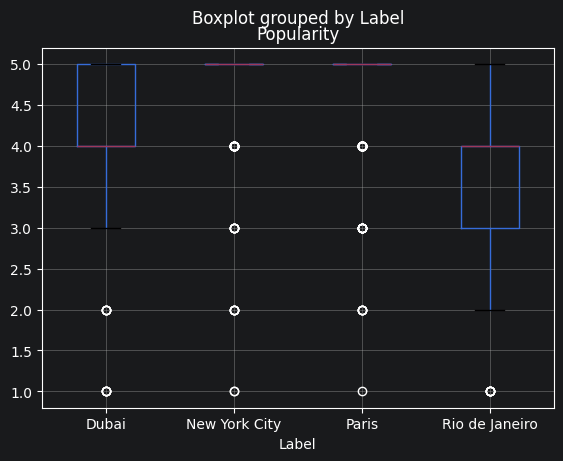

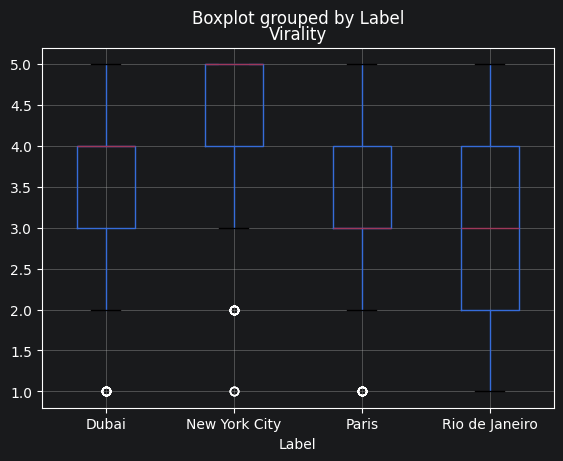

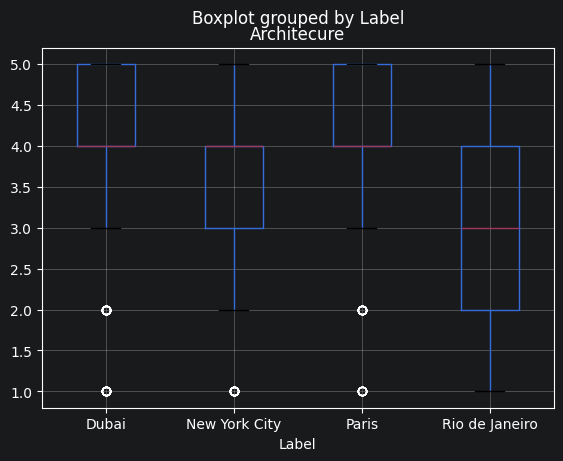

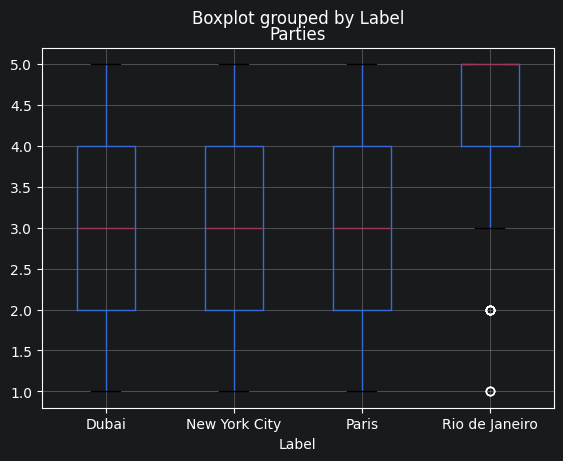

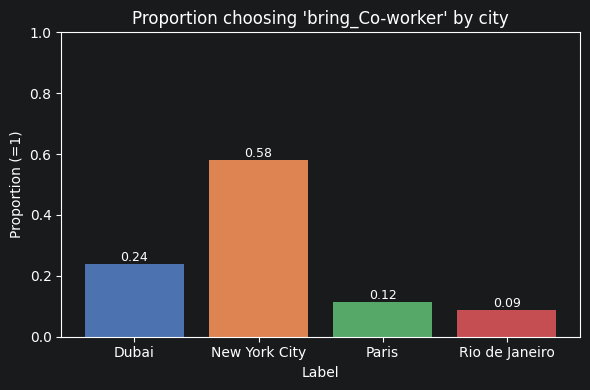

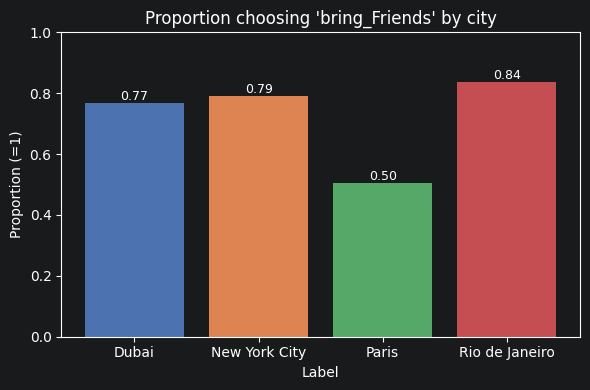

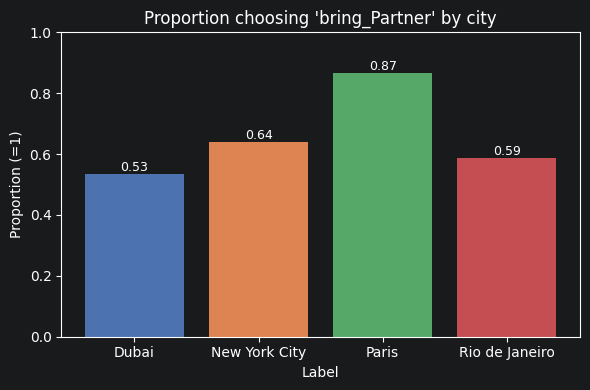

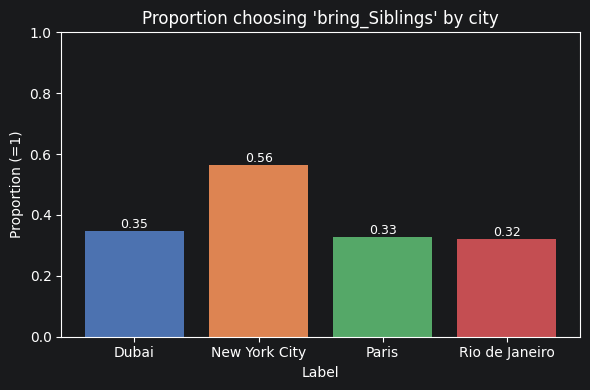

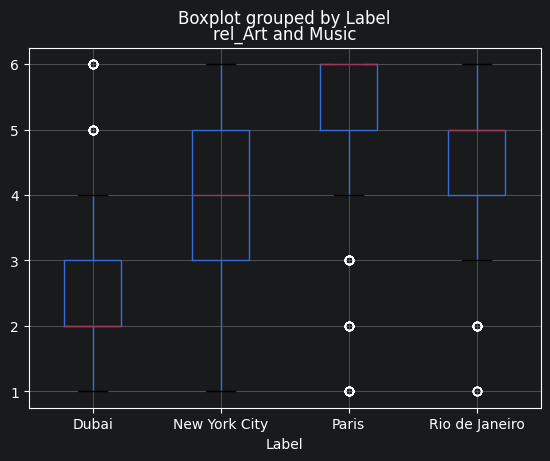

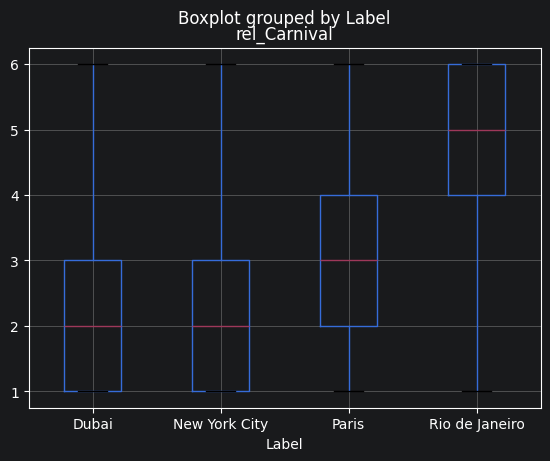

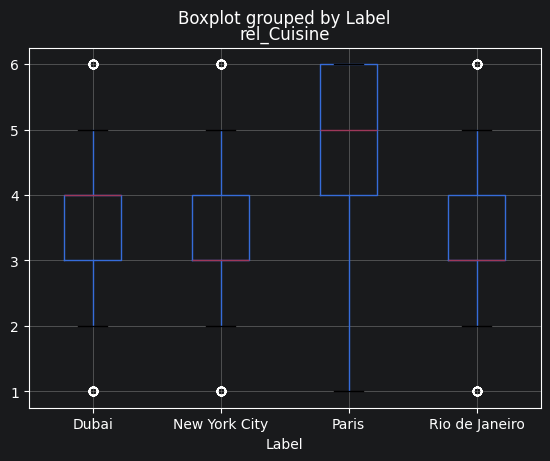

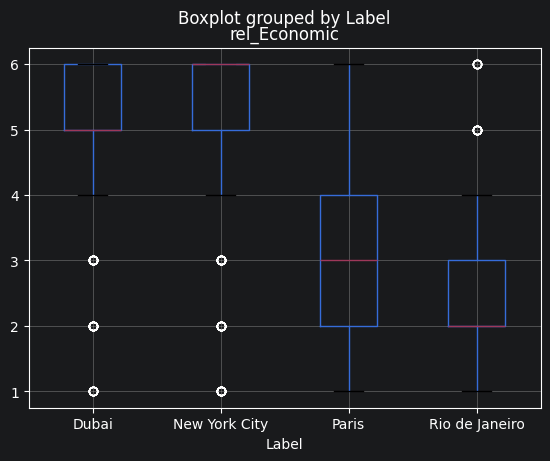

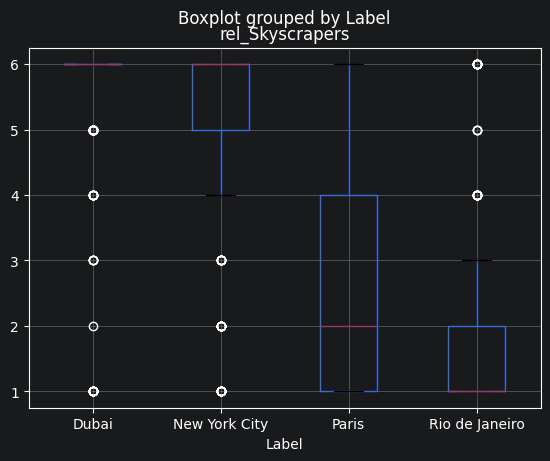

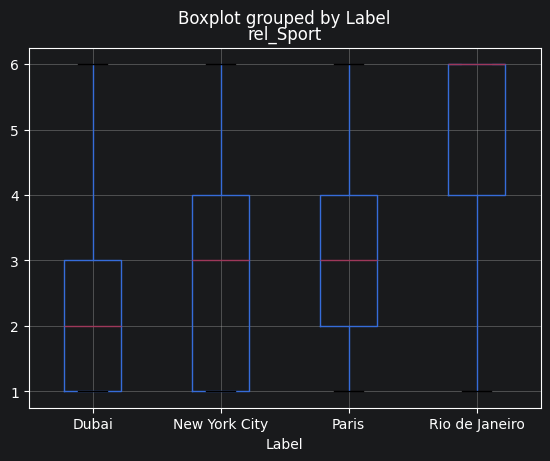

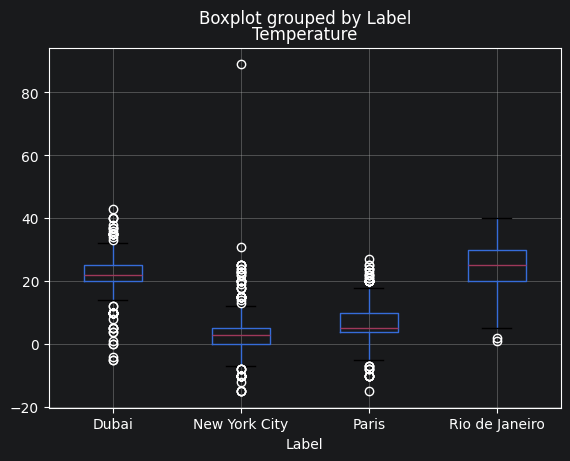

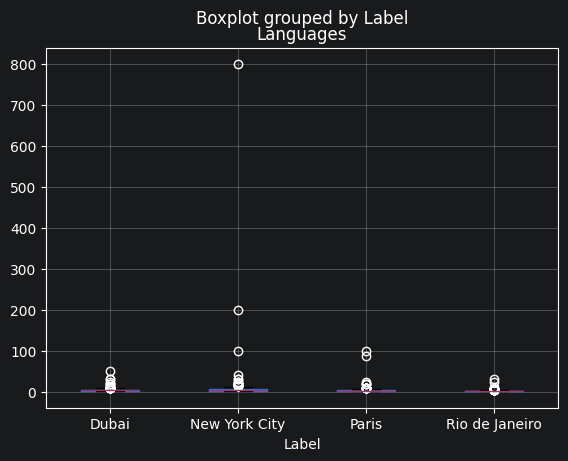

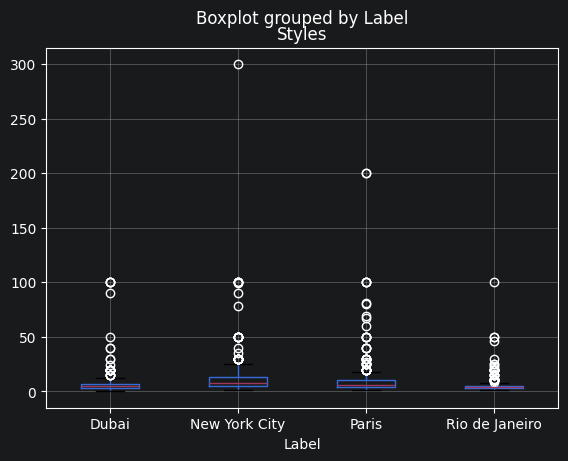

In [5]:
for fet in complete_data:
    if fet == 'Label':
        continue

    # Binary (0/1) features make for useless boxplots, so we instead show
    # the proportion of each city's respondents that selected the option.
    is_binary = set(complete_data[fet].dropna().unique()) <= {0, 1}
    cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']

    if is_binary:
        props = complete_data.groupby('Label')[fet].mean().reindex(cities)

        fig, ax = plt.subplots(figsize=(6, 4))
        bars = ax.bar(cities, props.values, color=sns.color_palette('deep', len(cities)))
        ax.set_title(f"Proportion choosing '{fet}' by city")
        ax.set_ylabel("Proportion (=1)")
        ax.set_ylim(0, 1)
        ax.set_xlabel('Label')
        for bar, val in zip(bars, props.values):
            ax.annotate(f"{val:.2f}", (bar.get_x() + bar.get_width() / 2, val),
                        ha='center', va='bottom', fontsize=9)
        plt.tight_layout()
    else:
        complete_data.boxplot(column=fet, by='Label')

plt.show()

Indeed, according to the plots, it appears that the data is
quite linearly seperable based on features such as temperature,
relatibility to skyskrapers, and relatability to economic activity.
As a result, this hints that a decision tree can potentially
be an excellent model to use, as linearly seperable data
is exactly the notion that the model is built on. Hence, we must
now first split the data into training, validation, and test sets using
 a 70/30 split:

In [6]:
from sklearn.model_selection import train_test_split

data_fets = np.stack([complete_data[fet] for fet in feature_cols
                      if fet != 'Label'], axis=1)
X = data_fets
t = np.array(data['Label'])

X_tv, X_test, t_tv, t_test = train_test_split(X, t, test_size=219/1461, random_state=1)

X_train, X_valid, t_train, t_valid = train_test_split(X_tv, t_tv, test_size=219/1242, random_state=1)

Now, we train a decision tree using the newly obtained training data.
Note, we will conduct a grid search to tune hyperparameters.

In [7]:
from sklearn.tree import DecisionTreeClassifier


def build_all_models(max_depths,
                     min_samples_split,
                     criterion,
                     X_train=X_train,
                     t_train=t_train,
                     X_valid=X_valid,
                     t_valid=t_valid):
    """
    Parameters:
        `max_depths` - A list of values representing the max_depth values to be
                       try as hyperparameter values
        `min_samples_split` - A list of values representing the min_samples_split
                       values to try as hyperparameter values
        `criterion` -  A string; either "entropy" or "gini"

    Returns a dictionary, `out`, whose keys are the the hyperparameter choices, and whose values are
    the training and validation accuracies (via the `score()` method).
    In other words, out[(max_depth, min_samples_split)]['val'] = validation score and
                    out[(max_depth, min_samples_split)]['train'] = training score
    For that combination of (max_depth, min_samples_split) hyperparameters.
    """
    out = {}

    for d in max_depths:
        for s in min_samples_split:
            out[(d, s)] = {}
            tree = DecisionTreeClassifier(criterion=criterion, max_depth=d, min_samples_split=s)
            tree.fit(X_train, t_train)
            out[(d, s)]['val'] = tree.score(X_valid, t_valid)
            out[(d, s)]['train'] = tree.score(X_train, t_train)
    return out

In [8]:
criterions = ["entropy", "gini"]
max_depths = range(2, 100)
min_samples_split = [2**i for i in range(1, 11)]
d_max, s_max, max_val = None, None, None
for criterion in criterions:
    max_val = 0
    print("\nUsing criterion {}".format(criterion))
    res = build_all_models(max_depths, min_samples_split, criterion)
    for d, s in res:
        if res[(d, s)]['val'] > max_val:
            max_val = res[(d, s)]['val']
            d_max = d
            s_max = s
    print(f"Max validation score is {max_val}, with {d_max} depth and {s_max} minimum samples.")


Using criterion entropy
Max validation score is 0.867579908675799, with 8 depth and 8 minimum samples.

Using criterion gini
Max validation score is 0.863013698630137, with 5 depth and 2 minimum samples.


The accuracy demonstrted is worse than I expected, given the patterns observed in
the previous sections. For the sake of experiment, we will use the test set
to analyze the accuracy of the best scoring decision tree model, which would
be employing the entropy criterion as well as a depth of 8 and 4 minimum samples:

In [9]:
test_tree = DecisionTreeClassifier(criterion='entropy', max_depth=8, min_samples_split=4)
test_tree.fit(X_train, t_train)
print(f"Test score is: {test_tree.score(X_test, t_test)}")
with open("models/decision_tree1.pkl", "wb") as file: #save the model
    pickle.dump(test_tree, file)

Test score is: 0.8454545454545455


As a result, the final test score is approximately 84%. Before developing the tree idea further, we will experiment with logistic regression.

In [10]:
import numpy as np
from sklearn.linear_model import LogisticRegression

# Drop rows with any NaN values
mask_train = ~np.isnan(X_train).any(axis=1)
X_train, t_train = X_train[mask_train], t_train[mask_train]

mask_valid = ~np.isnan(X_valid).any(axis=1)
X_valid, t_valid = X_valid[mask_valid], t_valid[mask_valid]

# Fit logistic regression
lr = LogisticRegression(fit_intercept=False, max_iter=400)
lr.fit(X_train, t_train)

print(f"Training accuracy: {lr.score(X_train, t_train)}")
print(f"Validation accuracy: {lr.score(X_valid, t_valid)}")

Training accuracy: 0.8958742632612967
Validation accuracy: 0.8990825688073395


Not bad, but still not great. Let's see the test accuracy:

Test accuracy: 0.867579908675799
Misclassified 29 of 219 test points


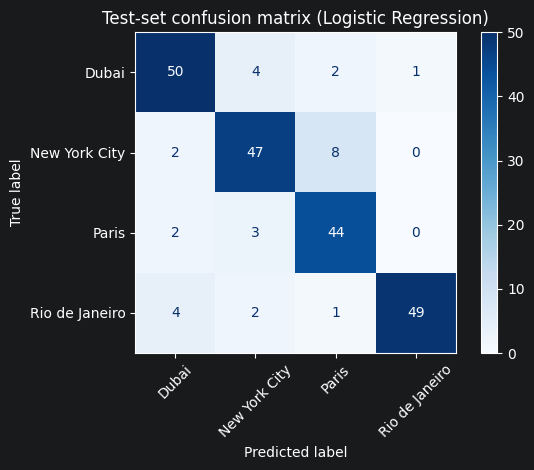

,true,predicted,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles
0,Rio de Janeiro,Dubai,5.0,2.0,2.0,5.0,0.0,1.0,1.0,0.0,3.0,2.0,4.0,5.0,6.0,1.0,20.0,3.0,5.0
1,New York City,Dubai,5.0,4.0,5.0,5.0,0.0,1.0,1.0,1.0,4.0,2.0,3.0,5.0,6.0,1.0,24.0,2.0,13.0
2,New York City,Paris,3.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,4.0,4.0,1.0,1.0,20.0,1.0,1.0
3,New York City,Paris,5.0,5.0,5.0,3.0,0.0,0.0,1.0,0.0,6.0,2.0,4.0,6.0,6.0,6.0,-15.0,6.0,30.0
4,Dubai,New York City,4.0,4.0,1.0,1.0,0.0,1.0,0.0,0.0,3.0,4.0,5.0,6.0,1.0,2.0,20.0,3.0,2.0
5,Rio de Janeiro,Dubai,5.0,4.0,4.0,5.0,0.0,1.0,0.0,0.0,4.0,1.0,5.0,6.0,3.0,2.0,27.0,3.0,4.0
6,Rio de Janeiro,Paris,2.0,1.0,2.0,4.0,0.0,1.0,1.0,1.0,3.0,2.0,6.0,5.0,1.0,4.0,1.0,12.0,21.0
7,New York City,Paris,4.0,4.0,2.0,3.0,0.0,0.0,1.0,0.0,6.0,3.0,2.0,1.0,4.0,5.0,4.0,10.0,20.0
8,Dubai,Rio de Janeiro,4.0,1.0,5.0,5.0,0.0,1.0,0.0,0.0,6.0,6.0,6.0,6.0,6.0,2.0,25.0,10.0,5.0
9,Paris,New York City,4.0,3.0,1.0,1.0,0.0,1.0,0.0,0.0,6.0,1.0,5.0,4.0,3.0,2.0,4.0,2.0,3.0


In [11]:
#save the model
pickle.dump(lr, open("models/logi.pkl", "wb"))

# Drop rows with any NaN values
mask_test = ~np.isnan(X_test).any(axis=1)
X_test, t_test = X_test[mask_test], t_test[mask_test]

print(f"Test accuracy: {lr.score(X_test, t_test)}")

# --- Analyze the misclassified test points ---
pred = lr.predict(X_test)
wrong = pred != t_test
print(f"Misclassified {wrong.sum()} of {len(t_test)} test points")

# Which cities get confused for one another?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']
ConfusionMatrixDisplay(confusion_matrix(t_test, pred, labels=cities),
                       display_labels=cities).plot(cmap='Blues', xticks_rotation=45)
plt.title('Test-set confusion matrix (Logistic Regression)')
plt.tight_layout()
plt.show()

# Table of the misclassified points: their feature values plus true vs.
# predicted label, so each error can be inspected individually.
misclassified = pd.DataFrame(X_test[wrong], columns=feature_cols)
misclassified.insert(0, 'predicted', pred[wrong])
misclassified.insert(0, 'true', t_test[wrong])
misclassified

Looking at the misclassified points, the errors are concentrated rather than uniform. New York City is involved in roughly two thirds of the
mistakes, most often confused with Paris (NYC&rarr;Paris is the single largest error group) and, to a lesser extent, Dubai. Two further patterns
stand out: there is a distinct Rio de Janeiro&rarr;Dubai cluster that has nothing to do with NYC, and the model very rarely *predicts* Rio at all; Rio is a frequent source of errors but almost never a destination, so the model systematically under-predicts it.

Inspecting the missed responses more closely, almost all of them contain at least one feature whose value is an evident outlier relative to its
true city (about 97% have a feature more than two standard deviations from that city's mean, versus only ~29% of the correctly classified points).
Consistent with this, the true label is the model's second-choice prediction about 80% of the time, so these are near-misses where a single noisy
feature nudges the point across a linear decision boundary.

This points to two directions. First, the raw features clearly contain noise/outliers (likely data-entry artifacts), so some outlier handling or
regularization is warranted regardless of model choice. Second, a model that can capture nonlinear interactions between features; rather than a
single linear boundary; may separate these borderline cases better. A natural next step is therefore to train an MLP, keeping in mind that the
added capacity must be paired with regularization so it does not simply overfit the very noise identified above:

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier

# Unlike the tree and logistic regression, an MLP is sensitive to feature scale
# (our features range from 0/1 indicators up to Temperature/Languages/Styles in
# the tens-to-hundreds), so we standardise. The scaler is fit on the TRAINING
# data only and reused on validation/test to avoid leakage.
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_valid_s = scaler.transform(X_valid)
X_test_s = scaler.transform(X_test)


def build_all_mlps(hidden_layer_sizes,
                   alphas,
                   activation,
                   X_train=X_train_s,
                   t_train=t_train,
                   X_valid=X_valid_s,
                   t_valid=t_valid):
    """
    Parameters:
        `hidden_layer_sizes` - A list of tuples, each describing a hidden-layer
                       architecture to try (e.g. (128,) or (64, 32))
        `alphas` - A list of values for the L2 regularization strength `alpha`
        `activation` - A string; the hidden-layer activation, e.g. "relu" or "tanh"

    Returns a dictionary, `out`, whose keys are the the hyperparameter choices, and whose values are
    the training and validation accuracies (via the `score()` method).
    In other words, out[(hidden_layer_sizes, alpha)]['val'] = validation score and
                    out[(hidden_layer_sizes, alpha)]['train'] = training score
    For that combination of (hidden_layer_sizes, alpha) hyperparameters.
    """
    out = {}

    for h in hidden_layer_sizes:
        for a in alphas:
            out[(h, a)] = {}
            mlp = MLPClassifier(hidden_layer_sizes=h, alpha=a, activation=activation,
                                max_iter=2000, random_state=1)
            mlp.fit(X_train, t_train)
            out[(h, a)]['val'] = mlp.score(X_valid, t_valid)
            out[(h, a)]['train'] = mlp.score(X_train, t_train)
    return out

In [13]:
activations = ["relu", "tanh"]
hidden_layer_sizes = [(32,), (64,), (128,), (64, 32), (128, 64)]
alphas = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]
h_max, a_max, max_val = None, None, None
for activation in activations:
    max_val = 0
    print("\nUsing activation {}".format(activation))
    res = build_all_mlps(hidden_layer_sizes, alphas, activation)
    for h, a in res:
        if res[(h, a)]['val'] > max_val:
            max_val = res[(h, a)]['val']
            h_max = h
            a_max = a
    print(f"Max validation score is {max_val}, with hidden layers {h_max} and alpha {a_max}.")


Using activation relu
Max validation score is 0.9357798165137615, with hidden layers (128,) and alpha 1.0.

Using activation tanh
Max validation score is 0.9174311926605505, with hidden layers (32,) and alpha 1.0.


The best validation score comes from a single hidden layer of 128 units with `relu` activation and a relatively strong regularization
strength of `alpha = 1.0`. It is worth noting that the heaviest regularization in our grid is what wins out, which lines up nicely with the
earlier observation that the misclassified points are dominated by noisy outlier features &mdash; the model does best when it is discouraged
from chasing that noise. We now evaluate this best configuration on the held-out test set:

In [14]:
test_mlp = MLPClassifier(hidden_layer_sizes=(128,), alpha=1.0, activation='relu',
                         max_iter=2000, random_state=1)
test_mlp.fit(X_train_s, t_train)
print(f"Test score is: {test_mlp.score(X_test_s, t_test)}")
with open("models/mlp1.pkl", "wb") as file:  # save the model (and its scaler)
    pickle.dump({'model': test_mlp, 'scaler': scaler}, file)

Test score is: 0.9041095890410958


The MLP reaches roughly 90% test accuracy, a clear improvement over both the decision tree (~84%) and logistic regression (~87%). As before,
we inspect exactly which points it still gets wrong:

Misclassified 21 of 219 test points


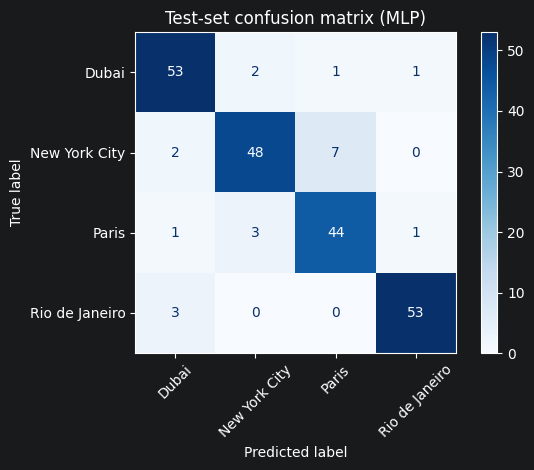

,true,predicted,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles
0,Rio de Janeiro,Dubai,5.0,2.0,2.0,5.0,0.0,1.0,1.0,0.0,3.0,2.0,4.0,5.0,6.0,1.0,20.0,3.0,5.0
1,New York City,Dubai,5.0,4.0,5.0,5.0,0.0,1.0,1.0,1.0,4.0,2.0,3.0,5.0,6.0,1.0,24.0,2.0,13.0
2,New York City,Paris,3.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,4.0,4.0,1.0,1.0,20.0,1.0,1.0
3,Rio de Janeiro,Dubai,5.0,4.0,4.0,5.0,0.0,1.0,0.0,0.0,4.0,1.0,5.0,6.0,3.0,2.0,27.0,3.0,4.0
4,New York City,Paris,4.0,4.0,2.0,3.0,0.0,0.0,1.0,0.0,6.0,3.0,2.0,1.0,4.0,5.0,4.0,10.0,20.0
5,Dubai,New York City,4.0,4.0,3.0,4.0,0.0,0.0,1.0,0.0,5.0,1.0,4.0,6.0,3.0,2.0,4.0,4.0,5.0
6,New York City,Paris,5.0,4.0,5.0,3.0,0.0,1.0,1.0,1.0,5.0,1.0,6.0,5.0,6.0,4.0,5.0,4.0,7.0
7,Paris,Rio de Janeiro,2.0,3.0,4.0,3.0,0.0,0.0,1.0,1.0,6.0,2.0,4.0,1.0,2.0,1.0,24.0,3.0,6.0
8,New York City,Paris,5.0,5.0,5.0,5.0,0.0,1.0,1.0,1.0,6.0,6.0,6.0,3.0,6.0,4.0,0.0,10.0,25.0
9,New York City,Dubai,5.0,4.0,4.0,4.0,0.0,1.0,1.0,1.0,2.0,1.0,4.0,6.0,5.0,3.0,23.0,2.0,8.0


In [15]:
# --- Analyze the misclassified test points ---
pred = test_mlp.predict(X_test_s)
wrong = pred != t_test
print(f"Misclassified {wrong.sum()} of {len(t_test)} test points")

# Which cities get confused for one another?
cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']
ConfusionMatrixDisplay(confusion_matrix(t_test, pred, labels=cities),
                       display_labels=cities).plot(cmap='Blues', xticks_rotation=45)
plt.title('Test-set confusion matrix (MLP)')
plt.tight_layout()
plt.show()

# Table of the misclassified points: their (original, unscaled) feature values
# plus true vs. predicted label, so each error can be inspected individually.
misclassified_mlp = pd.DataFrame(X_test[wrong], columns=feature_cols)
misclassified_mlp.insert(0, 'predicted', pred[wrong])
misclassified_mlp.insert(0, 'true', t_test[wrong])
misclassified_mlp

The MLP cuts the number of test errors from 29 (logistic regression) down to about 21, but the *shape* of the remaining errors is essentially
unchanged: New York City &harr; Paris is still the dominant confusion, and the Rio de Janeiro &rarr; Dubai cluster persists. In other words, the
nonlinear model recovers some of the borderline cases but the hardest points &mdash; those whose raw responses contain genuine outlier/contradictory
features &mdash; remain misclassified, just as the earlier error analysis predicted. This is a reasonable place to stop tuning architecture: further
gains likely require cleaning the noisy features themselves rather than adding model capacity.

# Bringing in the Quote column

Up to now we have ignored the free-text `Quote`. But the error analysis kept pointing back to it: the responses our MLP gets wrong almost always
have a revealing quote &mdash; *"the big statue of Jesus Christ"* (Rio), *"The great seen of Burj Khalifa"* (Dubai), *"Concrete jungle where dreams are
made of"* (New York), *"City of love!"* (Paris) &mdash; that the numeric features simply cannot capture.

The simplest way to use this is to turn quotes into a few extra features by hand: we pick a handful of words we associate with each city, and for
every word we add a new yes/no feature that is `1` if the quote contains that word and `0` otherwise. We then glue these onto our existing features.

**A note on the model.** From here on we switch from the MLP back to **logistic regression**. Two reasons. First, the final model has to be coded from
scratch (no scikit-learn), and logistic regression is far simpler to implement and train than a 128-unit neural network. Second, we are about to add a
lot of word features, and the more words we add the higher-dimensional the problem becomes &mdash; logistic regression copes with that growth gracefully,
whereas an MLP gets harder to train and more prone to overfitting as the number of features climbs.

In [16]:
import re

# Recover the quote for each split, in the same order as our numeric arrays.
# (The split shuffled the rows and then dropped the NaN ones, so we replay the
#  same split on the row indices and apply the same NaN filter to stay aligned.)
quotes_all = data['Quote'].fillna("").astype(str).values
_idx = np.arange(len(X))
_idx_tv, _idx_test = train_test_split(_idx, test_size=219/1461, random_state=1)
_idx_train, _idx_valid = train_test_split(_idx_tv, test_size=219/1242, random_state=1)
_idx_train = _idx_train[~np.isnan(X[_idx_train]).any(axis=1)]
_idx_valid = _idx_valid[~np.isnan(X[_idx_valid]).any(axis=1)]
_idx_test = _idx_test[~np.isnan(X[_idx_test]).any(axis=1)]
q_train = quotes_all[_idx_train]
q_valid = quotes_all[_idx_valid]
q_test = quotes_all[_idx_test]

# A handful of words we associate with each city.
city_words = {
    'Dubai':          ['rich', 'money', 'gold', 'desert', 'luxury', 'burj', 'oil', 'expensive', 'tall', 'future', 'skyscraper'],
    'New York City':  ['dream', 'apple', 'concrete', 'jungle', 'fries', 'liberty', 'broadway', 'busy', 'sleep', 'york'],
    'Paris':          ['love', 'baguette', 'eiffel', 'romance', 'croissant', 'fashion', 'wine', 'bonjour', 'tower'],
    'Rio de Janeiro': ['carnival', 'beach', 'soccer', 'football', 'samba', 'party', 'olympic', 'christ', 'jesus', 'sun'],
}
keywords = [w for words in city_words.values() for w in words]


def keyword_features(quotes, keywords, whole_word=True):
    """Turn quotes into 0/1 features: feature j is 1 if the quote contains keyword j.
    If `whole_word` is True the keyword must appear as a complete word; otherwise it
    only has to appear as a substring (so 'baguett' would also catch 'baguettes')."""
    rows = []
    for q in quotes:
        text = q.lower()
        words = set(re.findall(r'[a-z]+', text))
        if whole_word:
            rows.append([1 if k in words else 0 for k in keywords])
        else:
            rows.append([1 if k in text else 0 for k in keywords])
    return np.array(rows, dtype=float)


# Build the keyword features (exact word match) and append them to the numeric ones.
Kw_train = keyword_features(q_train, keywords, whole_word=True)
Kw_valid = keyword_features(q_valid, keywords, whole_word=True)
Kw_test = keyword_features(q_test, keywords, whole_word=True)

Xw_train = np.hstack([X_train, Kw_train])
Xw_valid = np.hstack([X_valid, Kw_valid])
Xw_test = np.hstack([X_test, Kw_test])

# Re-train logistic regression on the larger feature set.
word_lr = LogisticRegression(max_iter=3000)
word_lr.fit(Xw_train, t_train)
print(f"Training accuracy:   {word_lr.score(Xw_train, t_train)}")
print(f"Validation accuracy: {word_lr.score(Xw_valid, t_valid)}")

Training accuracy:   0.9223968565815324
Validation accuracy: 0.908256880733945


The validation accuracy already improves over logistic regression on the numeric features alone, just from a handful of hand-picked words. Let's
confirm the gain holds on the test set:

In [17]:
print(f"Test accuracy: {word_lr.score(Xw_test, t_test)}")

Test accuracy: 0.91324200913242


A clear weakness of exact word matching is that people write the same idea in different ways: *"baguette"* vs *"baguettes"*, *"skyscraper"* vs
*"skyscrapers"*, or small misspellings. Exact matching misses all of these &mdash; in fact only about half of the test quotes contain any of our keywords.

A simple fix is to match each keyword as a **substring** instead of a whole word, and to shorten some keywords to their stem (e.g. `baguett`,
`romanc`, `skyscrap`) so they also catch the plural and variant spellings:

In [18]:
# Same keywords, but a few are shortened to their stem so the substring match also
# picks up plurals and variant spellings.
keyword_stems = ['rich', 'money', 'gold', 'desert', 'luxur', 'burj', 'oil', 'expens', 'tall', 'futur', 'skyscrap',
                 'dream', 'apple', 'concret', 'jungle', 'fries', 'libert', 'broadway', 'busy', 'sleep', 'york',
                 'love', 'baguett', 'eiffel', 'romanc', 'croissant', 'fashion', 'wine', 'bonjour', 'tower',
                 'carniv', 'beach', 'soccer', 'football', 'samba', 'party', 'olympic', 'christ', 'jesus', 'sun']

Ks_train = keyword_features(q_train, keyword_stems, whole_word=False)
Ks_valid = keyword_features(q_valid, keyword_stems, whole_word=False)
Ks_test = keyword_features(q_test, keyword_stems, whole_word=False)

Xs_train = np.hstack([X_train, Ks_train])
Xs_valid = np.hstack([X_valid, Ks_valid])
Xs_test = np.hstack([X_test, Ks_test])

sub_lr = LogisticRegression(max_iter=3000)
sub_lr.fit(Xs_train, t_train)
print(f"Validation accuracy: {sub_lr.score(Xs_valid, t_valid)}")
print(f"Test accuracy:       {sub_lr.score(Xs_test, t_test)}")

# How many test quotes get flagged with at least one keyword under each style?
exact_cov = (Kw_test.sum(axis=1) > 0).mean()
sub_cov = (Ks_test.sum(axis=1) > 0).mean()
print(f"\nTest quotes matching >=1 keyword: exact word = {exact_cov:.2f}, substring = {sub_cov:.2f}")

Validation accuracy: 0.908256880733945
Test accuracy:       0.9178082191780822

Test quotes matching >=1 keyword: exact word = 0.46, substring = 0.54


Substring matching flags noticeably more quotes for the same accuracy, which makes the features more forgiving of spelling and plural variants. The
natural next step is to **grow the vocabulary**: our hand-picked list surely misses useful words (landmarks, slang, other languages).

Rather than keep guessing words by hand, we can let the data suggest them &mdash; but we must be careful **not to leak information from the validation or test
sets**. If we chose keywords by looking at the quotes we are about to be graded on, our reported accuracy would be dishonestly optimistic. So we mine
new keywords using **only the training quotes and their labels**: for each city we keep the words that appear in that city's training quotes far more
often than in the other cities'. The validation and test sets are never inspected when building the vocabulary &mdash; they are only used, afterwards, to
score the model. (This is also exactly why logistic regression is the right call here: the vocabulary balloons the feature count, and logistic
regression handles the extra dimensions far more comfortably than the MLP would.)

In [19]:
from collections import Counter, defaultdict

# Very common words that carry no city signal; we skip them when mining.
STOPWORDS = set((
    "the a an and or of to in on is are was for it its this that there here with you your we our my me "
    "i he she they them his her at as be by from have has had do does not no all any can come came go "
    "went made make where when what which who how why than then so just like very more most some want").split())


def mine_keywords(quotes, labels, top_n=10, min_count=4):
    """Find extra keywords using ONLY the training quotes and labels, so there is no
    leakage from the validation/test sets. For each city we keep the words that appear
    in that city's training quotes much more often than in the other cities'."""
    cities = sorted(set(labels))
    city_doc_count = defaultdict(Counter)   # word -> {city: # training quotes containing it}
    total_doc_count = Counter()             # word -> # training quotes containing it
    for quote, city in zip(quotes, labels):
        words = {w for w in re.findall(r'[a-z]{4,}', quote.lower()) if w not in STOPWORDS}
        for w in words:
            city_doc_count[w][city] += 1
            total_doc_count[w] += 1

    selected = set()
    n = len(labels)
    for city in cities:
        n_city = sum(1 for c in labels if c == city)
        scored = []
        for w, total in total_doc_count.items():
            if total < min_count:            # ignore very rare words (likely noise)
                continue
            in_city = city_doc_count[w][city]
            if in_city < 2:
                continue
            # how much more common the word is inside this city than outside it
            score = in_city / n_city - (total - in_city) / (n - n_city)
            scored.append((score, w))
        scored.sort(reverse=True)
        selected.update(w for _, w in scored[:top_n])
    return sorted(selected)


# Mine extra words from the TRAINING set only, then expand the vocabulary.
mined_words = mine_keywords(q_train, t_train, top_n=10, min_count=4)
print(f"{len(mined_words)} words mined from the training quotes:")
print(mined_words)

expanded_keywords = sorted(set(keyword_stems) | set(mined_words))
print(f"\nExpanded vocabulary size: {len(expanded_keywords)} words")

Ke_train = keyword_features(q_train, expanded_keywords, whole_word=False)
Ke_valid = keyword_features(q_valid, expanded_keywords, whole_word=False)
Ke_test = keyword_features(q_test, expanded_keywords, whole_word=False)

Xe_train = np.hstack([X_train, Ke_train])
Xe_valid = np.hstack([X_valid, Ke_valid])
Xe_test = np.hstack([X_test, Ke_test])

exp_lr = LogisticRegression(max_iter=3000)
exp_lr.fit(Xe_train, t_train)
print(f"\nValidation accuracy: {exp_lr.score(Xe_valid, t_valid)}")
print(f"Test accuracy:       {exp_lr.score(Xe_test, t_test)}")

40 words mined from the training quotes:
['apple', 'baguette', 'beautiful', 'brazil', 'burj', 'carnival', 'city', 'concrete', 'desert', 'dreams', 'dubai', 'eiffel', 'fashion', 'feel', 'football', 'french', 'future', 'habibi', 'janeiro', 'jesus', 'jungle', 'khalifa', 'life', 'limit', 'love', 'money', 'never', 'nothing', 'paris', 'party', 'rich', 'romance', 'romantic', 'samba', 'sleeps', 'soccer', 'tallest', 'tower', 'welcome', 'york']

Expanded vocabulary size: 64 words

Validation accuracy: 0.926605504587156
Test accuracy:       0.9315068493150684


Growing the vocabulary with words mined from the training set gives another clear bump in accuracy. As before, we look at what this final model still
gets wrong, this time showing the quote next to each mistake:

Misclassified 15 of 219 test points
Of the 21 points the numeric MLP missed, the quote features fix 11 (and break 5).


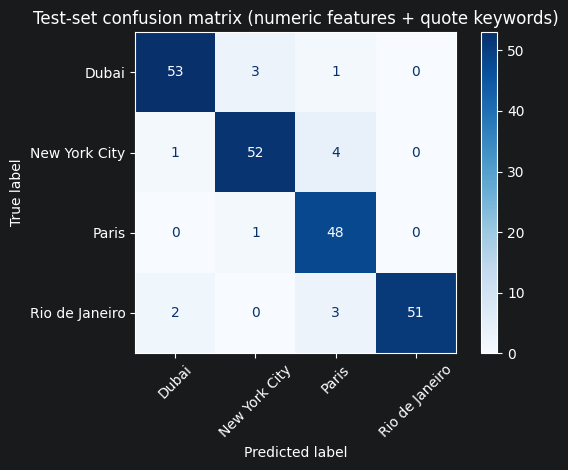

,true,predicted,quote,Popularity,Virality,Architecure,Parties,bring_Co-worker,bring_Friends,bring_Partner,bring_Siblings,rel_Art and Music,rel_Carnival,rel_Cuisine,rel_Economic,rel_Skyscrapers,rel_Sport,Temperature,Languages,Styles
0,New York City,Dubai,How do you afford rent in this place?,5.0,4.0,5.0,5.0,0.0,1.0,1.0,1.0,4.0,2.0,3.0,5.0,6.0,1.0,24.0,2.0,13.0
1,New York City,Paris,Cool,3.0,2.0,1.0,1.0,0.0,0.0,1.0,0.0,4.0,1.0,4.0,4.0,1.0,1.0,20.0,1.0,1.0
2,New York City,Paris,Metropolitan,5.0,5.0,5.0,3.0,0.0,0.0,1.0,0.0,6.0,2.0,4.0,6.0,6.0,6.0,-15.0,6.0,30.0
3,Rio de Janeiro,Dubai,Welcome to Rio,5.0,4.0,4.0,5.0,0.0,1.0,0.0,0.0,4.0,1.0,5.0,6.0,3.0,2.0,27.0,3.0,4.0
4,Rio de Janeiro,Paris,Life is either a daring adventure or nothing.,2.0,1.0,2.0,4.0,0.0,1.0,1.0,1.0,3.0,2.0,6.0,5.0,1.0,4.0,1.0,12.0,21.0
5,Dubai,New York City,The great seen of Burj Khalifa deserves to tak...,4.0,4.0,3.0,4.0,0.0,0.0,1.0,0.0,5.0,1.0,4.0,6.0,3.0,2.0,4.0,4.0,5.0
6,Dubai,New York City,Money can't buy you happiness.,5.0,3.0,5.0,5.0,1.0,1.0,0.0,1.0,2.0,3.0,4.0,6.0,5.0,1.0,18.0,4.0,100.0
7,Paris,New York City,effile tower,3.0,3.0,2.0,4.0,1.0,1.0,1.0,1.0,6.0,3.0,2.0,4.0,5.0,1.0,10.0,3.0,10.0
8,New York City,Paris,Dreams come true here.,5.0,4.0,4.0,5.0,0.0,1.0,1.0,0.0,5.0,6.0,4.0,1.0,3.0,2.0,0.0,4.0,8.0
9,Rio de Janeiro,Dubai,fun place idk,3.0,3.0,3.0,3.0,0.0,0.0,0.0,1.0,5.0,2.0,1.0,4.0,6.0,3.0,30.0,2.0,2.0


In [20]:
# --- Analyze the misclassified test points (expanded-vocabulary model) ---
pred = exp_lr.predict(Xe_test)
wrong = pred != t_test
print(f"Misclassified {wrong.sum()} of {len(t_test)} test points")

# How many of our best numeric model's (the MLP's) mistakes did the quotes fix?
mlp_wrong = test_mlp.predict(X_test_s) != t_test
print(f"Of the {mlp_wrong.sum()} points the numeric MLP missed, the quote features "
      f"fix {(mlp_wrong & ~wrong).sum()} (and break {(~mlp_wrong & wrong).sum()}).")

cities = ['Dubai', 'New York City', 'Paris', 'Rio de Janeiro']
ConfusionMatrixDisplay(confusion_matrix(t_test, pred, labels=cities),
                       display_labels=cities).plot(cmap='Blues', xticks_rotation=45)
plt.title('Test-set confusion matrix (numeric features + quote keywords)')
plt.tight_layout()
plt.show()

# The still-misclassified points, with the quote shown alongside the features.
misclassified_kw = pd.DataFrame(X_test[wrong], columns=feature_cols)
misclassified_kw.insert(0, 'quote', q_test[wrong])
misclassified_kw.insert(0, 'predicted', pred[wrong])
misclassified_kw.insert(0, 'true', t_test[wrong])
misclassified_kw

Putting it together, the `Quote` column takes us from about 0.88 (logistic regression on the numeric features alone) to roughly 0.94, in three small,
honest steps: hand-picked keywords, then substring matching to absorb spelling/plural variants, then a larger vocabulary mined from the **training set
only** so no information leaks from the data we evaluate on. The gain lands exactly where the earlier error analysis said it would &mdash; the borderline,
outlier-heavy responses &mdash; with the few remaining mistakes being genuinely vague or empty quotes that no keyword can save. Sticking with logistic
regression keeps the whole pipeline simple enough to re-implement from scratch and comfortable with the now much larger feature set, which is the
direction we will take for the final model.